# Human TPR Baseline and Model Statistical Tests

This notebook:
1. Prepares Manchester corpus metadata: generates `tpr_cached_inputs.csv` (consumed by `compute_analytical_metrics.py`) and `results/tpr/tpr_human_baseline.csv`
2. Processes the `data/CHILDES/tpr-data` corpus (17 other-adult dyads) to establish the adult TPR baseline
3. Validates corpus equivalence between Manchester and tpr-data
4. Runs four statistical tests per model against the human baseline
5. Exports `results/tpr/tpr_human_summary.csv` and `results/tpr/tpr_model_summary_analytical.csv`

**Run order:** Step 1 (`run_experiments.py discourse`) → **Step 2 (this notebook)** → Step 3 (`compute_analytical_metrics.py`) → Step 4 (`analysis.ipynb`)

In [1]:
import os
import glob
import pandas as pd
from pathlib import Path
import numpy as np
from scipy.stats import ttest_rel, ttest_ind, ttest_1samp
import matplotlib.pyplot as plt
import seaborn as sns

import cac_utils as cac
from determiner.pair_extractors import DeterminerNounExtractor

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

/Users/hjvm/anaconda3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


## 0. Prepare Manchester Corpus Metadata

Loads the Manchester CHILDES corpus, extracts D×N pairs, builds the restricted attested-noun set,
generates `output/manchester_tpr_childes/tpr_cached_inputs.csv` (consumed by
`compute_analytical_metrics.py`), and computes the restricted-noun human TPR baseline
(saved to `results/tpr/tpr_human_baseline.csv`).

The Manchester corpus variables (`old_corpus`, `old_det_noun_locations`, `old_out_dir`)
are reused in Section 5 to build the unrestricted baseline.

In [2]:
old_out_dir = "./output/manchester_tpr_childes"
os.makedirs(old_out_dir, exist_ok=True)
os.makedirs("./results/tpr", exist_ok=True)

print("Loading Manchester corpus...")
old_corpus = cac.load_manchester_corpus()
old_det_noun_locations = cac.load_or_extract_det_noun_locations(old_corpus, old_out_dir)

# Build restricted noun set (nouns both speakers used with both determiners per session)
print("\nBuilding attested noun set...")
old_attested_nouns = cac.find_attested_nouns_per_session(old_corpus, old_det_noun_locations)

# Generate tpr_cached_inputs.csv — TPR case metadata consumed by compute_analytical_metrics.py
print("\nGenerating TPR case metadata...")
cac.prepare_tpr_inputs_all_sessions(
    old_det_noun_locations,
    old_attested_nouns,
    old_out_dir,
    discourse_label_style="childes"
)

# Compute restricted Manchester TPR (used in Section 4 comparison against tpr-data restricted TPR)
print("\nComputing restricted Manchester human TPR baseline...")
_ = cac.calculate_tpr_human_baseline(
    old_corpus, old_det_noun_locations, old_attested_nouns,
    tpr_output_dir=old_out_dir,
    results_tpr_dir="./results/tpr"
)
print("Saved to ./results/tpr/tpr_human_baseline.csv")

Loading Manchester corpus...
Processing raw corpus files (this will be cached for future use)...
  Cleaning CHILDES annotations for Gail...


Loaded Gail: 18459 child utterances, 28596 mother utterances (47055 total in temporal order)


  Cleaning CHILDES annotations for Dominic...


Loaded Dominic: 24236 child utterances, 37411 mother utterances (61647 total in temporal order)
  Cleaning CHILDES annotations for Becky...


Loaded Becky: 27339 child utterances, 26772 mother utterances (54111 total in temporal order)
  Cleaning CHILDES annotations for Liz...


...

Loaded Nicole: 20328 child utterances, 30522 mother utterances (50850 total in temporal order)
  Cleaning CHILDES annotations for Warren...


Loaded Warren: 17813 child utterances, 25106 mother utterances (42919 total in temporal order)
Loading pre-extracted det-noun pairs from ./output/manchester_tpr_childes/det_noun_locations.csv
Loaded 75133 determiner-noun pairs

Building attested noun set...



Generating TPR case metadata...
  Loading cached inputs from ./output/manchester_tpr_childes/tpr_cached_inputs.csv

Computing restricted Manchester human TPR baseline...
  Calculating TPR for Gail...
  Calculating TPR for Dominic...
  Calculating TPR for Becky...
  Calculating TPR for Liz...
  Calculating TPR for Carl...


  Calculating TPR for Joel...
  Calculating TPR for Ruth...
  Calculating TPR for Aran...
  Calculating TPR for Anne...
  Calculating TPR for John...
  Calculating TPR for Nicole...
  Calculating TPR for Warren...


  Saved human baseline to ./results/tpr/tpr_human_baseline.csv
Saved to ./results/tpr/tpr_human_baseline.csv


In [3]:
# Augment tpr_cached_inputs.csv with `true_dist`: within-session utterance distance from the
# cross-speaker antecedent to the target (the antecedent is reset per session, so this never crosses
# recording sessions). Consumed downstream by the LM context-window analysis.
_streams = {}
for _child, _df in old_corpus.items():
    for _fn, _g in _df.groupby("filename"):
        _streams[(_child, os.path.basename(str(_fn)))] = np.sort(_g["line_num"].values)
_cache = os.path.join(old_out_dir, "tpr_cached_inputs.csv")
_tci = pd.read_csv(_cache)
def _true_dist(r):
    arr = _streams.get((r["child_name"], os.path.basename(str(r["filename"]))))
    if arr is None or pd.isna(r["previous_line_num"]):
        return np.nan
    return int(((arr > r["previous_line_num"]) & (arr < r["target_line_num"])).sum()) + 1
_tci["true_dist"] = _tci.apply(_true_dist, axis=1)
_tci.to_csv(_cache, index=False)
print(f"Added true_dist to {_cache}: {_tci.true_dist.notna().sum()}/{len(_tci)} cases, "
      f"median={_tci.true_dist.median():.0f}, mean={_tci.true_dist.mean():.1f}")

Added true_dist to ./output/manchester_tpr_childes/tpr_cached_inputs.csv: 12374/12374 cases, median=4, mean=83.2


## 1. Load Custom Transcript Corpus
We read the `.cha` files directly, parsing the lines containing `*CHI:` and `*MOT:`.

In [4]:
def load_tpr_data_corpus(data_dir):
    corpus_data = {}
    cha_files = glob.glob(os.path.join(data_dir, "*.cha"))
    
    for filepath in sorted(cha_files):
        child_name = os.path.basename(filepath).replace(".cha", "")
        
        rows = []
        line_num = 0
        with open(filepath, "r", encoding="utf-8", errors="replace") as f:
            for line in f:
                parts = line.strip().split(maxsplit=2)
                # Keep lines that start with a *, meaning they are speaker utterances
                if len(parts) >= 3 and parts[1].startswith("*"):
                    session_id = parts[0]
                    speaker = parts[1]
                    sentence = parts[2]
                    
                    if speaker == "*CHI:":
                        speaker_type = "child"
                    elif speaker == "*MOT:":
                        speaker_type = "mother"
                    else:
                        speaker_type = "other_adult"
                    
                    rows.append({
                        "filename": session_id,
                        "speaker": speaker,
                        "sentence": sentence,
                        "line_num": line_num,
                        "speaker_type": speaker_type
                    })
                line_num += 1
                
        if rows:
            df = pd.DataFrame(rows)
            # Clean any embedded CHILDES annotations
            df["sentence"] = df["sentence"].apply(cac.clean_childes_annotations)
            df = df[df["sentence"].str.strip() != ""].copy()
            corpus_data[child_name] = df
            
            n_child = len(df[df.speaker_type == 'child'])
            n_mother = len(df[df.speaker_type == 'mother'])
            n_other = len(df[df.speaker_type == 'other_adult'])
            print(f"Loaded {child_name}: {len(df)} utterances ({n_child} chi, {n_mother} mot, {n_other} other)")
            
    return corpus_data

data_dir = "data/CHILDES/tpr-data"
corpus = load_tpr_data_corpus(data_dir)

Loaded adam: 73427 utterances (46739 chi, 20344 mot, 6344 other)


Loaded alex: 72623 utterances (29249 chi, 38768 mot, 4606 other)


Loaded anne: 61189 utterances (22685 chi, 37418 mot, 1086 other)


Loaded aran: 54641 utterances (18293 chi, 35476 mot, 872 other)


Loaded becky: 56313 utterances (27339 chi, 26772 mot, 2202 other)


...

Loaded nina: 69138 utterances (33174 chi, 34552 mot, 1412 other)


Loaded peter: 60851 utterances (29521 chi, 3512 mot, 27818 other)


Loaded ruth: 58986 utterances (21433 chi, 36691 mot, 862 other)


Loaded warr: 43333 utterances (17812 chi, 25106 mot, 415 other)


Loaded william: 56370 utterances (21291 chi, 28853 mot, 6226 other)


## 2. Extract Determiner-Noun Locations

In [5]:
out_dir = "./output/tpr_data_analysis"
os.makedirs(out_dir, exist_ok=True)

# Setting cache_filename explicitly so it doesn't overwrite general cache
det_noun_locations = cac.load_or_extract_det_noun_locations(corpus, out_dir)
print(f"\nTotal Det-Noun pairs extracted: {len(det_noun_locations)}")

Loading pre-extracted det-noun pairs from ./output/tpr_data_analysis/det_noun_locations.csv
Loaded 180396 determiner-noun pairs

Total Det-Noun pairs extracted: 180396


## 3. TPR Computation

In [6]:
import cac_utils as cac

# Find attested nouns per session
attested_nouns = cac.find_attested_nouns_per_session(corpus, det_noun_locations)

# Calculate Human TPR strictly for the new subsets
new_human_tpr = cac.calculate_tpr_human_baseline(corpus, det_noun_locations, attested_nouns, out_dir)
new_human_tpr["tpr"] = (new_human_tpr["n_transitions_to_the"] + new_human_tpr["n_transitions_to_a"]) / new_human_tpr["n_total"].replace(0, np.nan)

print(f"\nNew human baseline shape: {new_human_tpr.shape}")

  Calculating TPR for adam...
  Calculating TPR for alex...
  Calculating TPR for anne...
  Calculating TPR for aran...
  Calculating TPR for becky...


  Calculating TPR for carl...
  Calculating TPR for ethan...
  Calculating TPR for joel...
  Calculating TPR for john...
  Calculating TPR for lara...


  Calculating TPR for lily...
  Calculating TPR for naima...


  Calculating TPR for nina...
  Calculating TPR for peter...


  Calculating TPR for ruth...
  Calculating TPR for warr...
  Calculating TPR for william...
  Saved human baseline to ./output/tpr_data_analysis/tpr_human_baseline.csv

New human baseline shape: (1980, 17)


## 4. Compare with Old Human TPR

In [7]:
old_human_tpr = pd.read_csv("./results/tpr/tpr_human_baseline.csv")

# Normalize child names for robust merging
new_human_tpr["child_name_norm"] = new_human_tpr["child_name"].str.lower().str.replace('warr', 'warren')
old_human_tpr["child_name_norm"] = old_human_tpr["child_name"].str.lower()

# Mathematically sound aggregation (summing counts before dividing)
def aggregate_soundly(df, prefix):
    agg = df.groupby(["child_name_norm", "speaker"]).agg({
        "n_transitions_to_the": "sum",
        "n_transitions_to_a": "sum",
        "n_total": "sum"
    }).reset_index()
    agg[prefix] = (agg["n_transitions_to_the"] + agg["n_transitions_to_a"]) / agg["n_total"]
    return agg[["child_name_norm", "speaker", prefix]]

new_agg = aggregate_soundly(new_human_tpr, "new_tpr")
old_agg = aggregate_soundly(old_human_tpr, "old_tpr")

comparison = pd.merge(old_agg, new_agg, on=["child_name_norm", "speaker"], how="outer").rename(columns={"child_name_norm": "child_name"})

print("Child-Level TPR Comparison (Old vs. New Data - Sound Aggregation):\n")
print(comparison.dropna().to_string(index=False))

for speaker in ["child", "mother"]:
    sub = comparison[comparison["speaker"] == speaker].dropna()
    if len(sub) > 1:
        t_stat, p_val = ttest_rel(sub["old_tpr"], sub["new_tpr"])
        print(f"\nPaired T-Test for {speaker.capitalize()}s - p-value: {p_val:.3f}")
        mean_diff = sub["new_tpr"].mean() - sub["old_tpr"].mean()
        print(f"Mean Diff ({speaker}s): {mean_diff:+.3f}")

Child-Level TPR Comparison (Old vs. New Data - Sound Aggregation):

child_name speaker  old_tpr  new_tpr
      anne   child 0.210526 0.207547
      anne  mother 0.338028 0.318182
      aran   child 0.362538 0.367601
      aran  mother 0.193634 0.196721
     becky   child 0.287500 0.304878
     becky  mother 0.239130 0.241758
      carl   child 0.329412 0.327014
      carl  mother 0.256356 0.256900
      joel   child 0.288462 0.312500
      joel  mother 0.240741 0.230769
      john   child 0.397590 0.387500
      john  mother 0.327957 0.321839
      ruth   child 0.367347 0.371134
      ruth  mother 0.313725 0.317308
    warren   child 0.297935 0.303571
    warren  mother 0.302632 0.308511

Paired T-Test for Childs - p-value: 0.239
Mean Diff (childs): +0.005

Paired T-Test for Mothers - p-value: 0.444
Mean Diff (mothers): -0.003


### Mother -> Other Adult Exploratory Analysis
Let's take a look at the statistics specifically for `other_adult` responses following a `mother` utterance, tracking the transitions to *a* vs *the*.

In [8]:
# Filter new dataset to isolate the third transition pairing logic entirely
other_adult_df = new_human_tpr[new_human_tpr['speaker'] == 'other_adult'].copy()

# Calculate raw probabilities identically matching baseline calculations
other_adult_df['tpr'] = (other_adult_df['n_transitions_to_the'] + other_adult_df['n_transitions_to_a']) / other_adult_df['n_total'].replace(0, np.nan)
other_adult_df['tpr_the'] = other_adult_df['n_transitions_to_the'] / other_adult_df['n_previous_a'].replace(0, np.nan)
other_adult_df['tpr_a'] = other_adult_df['n_transitions_to_a'] / other_adult_df['n_previous_the'].replace(0, np.nan)

print("Overall Phase Summary (Mother -> Other Adult):")
print(other_adult_df[['tpr', 'tpr_the', 'tpr_a']].describe().loc[['mean', 'std', 'count', 'min', 'max']].round(3))

print("\n---")
print("\nAggregated TPR per Dyad context:")
other_adult_agg = other_adult_df.groupby('child_name')[['n_total', 'tpr', 'tpr_the', 'tpr_a']].agg({
    'n_total': 'sum',
    'tpr': 'mean',
    'tpr_the': 'mean',
    'tpr_a': 'mean'
}).rename(columns={'n_total': 'total_observations'}).round(3).reset_index()

other_adult_agg

Overall Phase Summary (Mother -> Other Adult):
          tpr  tpr_the   tpr_a
mean    0.390    0.439   0.317
std     0.432    0.485   0.405
count  98.000   63.000  55.000
min     0.000    0.000   0.000
max     1.000    1.000   1.000

---

Aggregated TPR per Dyad context:


,child_name,total_observations,tpr,tpr_the,tpr_a
0,adam,7,0.300,0.333,0.167
1,alex,4,0.500,1.000,0.333
2,anne,3,0.000,NaN,0.000
3,aran,8,0.250,0.500,0.083
4,becky,3,0.333,0.333,NaN
5,carl,9,0.500,0.600,0.333
6,ethan,2,0.500,0.000,1.000
7,joel,11,0.389,0.375,0.250
8,john,11,0.556,0.600,0.500
9,lara,25,0.323,0.214,0.448


In [9]:
other_adult_df

,child_name,filename,speaker,source,model_name,model_type,n_attested_nouns,tpr_the,tpr_a,tpr_overall,n_transitions_to_the,n_transitions_to_a,n_previous_a,n_previous_the,n_maintained,n_total,tpr,child_name_norm
2,adam,adam20,other_adult,human,Human,baseline,1,NaN,NaN,NaN,0,0,0,0,0,0,NaN,adam
5,adam,adam21,other_adult,human,Human,baseline,3,NaN,NaN,NaN,0,0,0,0,0,0,NaN,adam
8,adam,adam22,other_adult,human,Human,baseline,4,1.0,NaN,1.0,1,0,1,0,0,1,1.0,adam
11,adam,adam23,other_adult,human,Human,baseline,5,NaN,NaN,NaN,0,0,0,0,0,0,NaN,adam
14,adam,adam24,other_adult,human,Human,baseline,6,NaN,NaN,NaN,0,0,0,0,0,0,NaN,adam
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1967,william,030125,other_adult,human,Human,baseline,14,NaN,0.0,0.0,0,0,0,1,1,1,0.0,william
1970,william,030221,other_adult,human,Human,baseline,14,NaN,NaN,NaN,0,0,0,0,0,0,NaN,william
1973,william,030305,other_adult,human,Human,baseline,14,NaN,NaN,NaN,0,0,0,0,0,0,NaN,william
1976,william,030325,other_adult,human,Human,baseline,14,NaN,NaN,NaN,0,0,0,0,0,0,NaN,william


In [10]:
# Calculate the true global aggregate by summing the raw counts first
# NOTE: This is computed on the RESTRICTED noun set (only nouns attested with both determiners)
global_counts = other_adult_df[['n_transitions_to_the', 'n_transitions_to_a', 'n_previous_a', 'n_previous_the', 'n_total']].sum()

global_tpr = (global_counts['n_transitions_to_the'] + global_counts['n_transitions_to_a']) / global_counts['n_total']
global_tpr_the = global_counts['n_transitions_to_the'] / global_counts['n_previous_a']
global_tpr_a = global_counts['n_transitions_to_a'] / global_counts['n_previous_the']

print(f"Global Aggregate TPR (Mother -> Other Adult - RESTRICTED NOUN SET):")
print(f"Total Observations: {int(global_counts['n_total'])}")
print(f"Global TPR:     {global_tpr:.3f}")
print(f"Global TPR_the: {global_tpr_the:.3f}")
print(f"Global TPR_a:   {global_tpr_a:.3f}")

Global Aggregate TPR (Mother -> Other Adult - RESTRICTED NOUN SET):
Total Observations: 176
Global TPR:     0.335
Global TPR_the: 0.395
Global TPR_a:   0.284


In [11]:
# ===== RESTRICTED NOUN SET ANALYSIS  =====
# The following cells (16-18) analyze data using ONLY nouns attested with both *the* and *a*
# in both child and mother speecha
# ================================================================================

# Get child-level aggregated TPRs for the original mothers and children using the sound aggregate function
old_child_tprs = old_agg[old_agg['speaker'] == 'child']['old_tpr'].dropna()
old_mother_tprs = old_agg[old_agg['speaker'] == 'mother']['old_tpr'].dropna()

# Get child-level aggregated TPRs for the new other_adult using the sound aggregate function
oa_tprs = new_agg[new_agg['speaker'] == 'other_adult']['new_tpr'].dropna()

print("--- Aggregate Mean TPRs ---")
print(f"mother->child:      {old_child_tprs.mean():.3f} (n={len(old_child_tprs)} dyads)")
print(f"child->mother:     {old_mother_tprs.mean():.3f} (n={len(old_mother_tprs)} dyads)")
print(f"mother->other_adult:     {oa_tprs.mean():.3f} (n={len(oa_tprs)} dyads)\n")

# Run independent t-tests (Welch's t-test allowing for unequal variances/sample sizes)
t_c, p_c = ttest_ind(oa_tprs, old_child_tprs, equal_var=False)
t_m, p_m = ttest_ind(oa_tprs, old_mother_tprs, equal_var=False)

print("--- Statistical Tests (Welch's Independent T-Test) ---")
print(f"mother->other_adult vs. mother->child:  t-stat = {t_c:+.3f}, p-value = {p_c:.3f}")
print(f"mother->other_adult vs. child->mother: t-stat = {t_m:+.3f}, p-value = {p_m:.3f}")


--- Aggregate Mean TPRs ---
mother->child:      0.336 (n=12 dyads)
child->mother:     0.303 (n=12 dyads)
mother->other_adult:     0.324 (n=17 dyads)

--- Statistical Tests (Welch's Independent T-Test) ---
mother->other_adult vs. mother->child:  t-stat = -0.234, p-value = 0.817
mother->other_adult vs. child->mother: t-stat = +0.400, p-value = 0.693


In [12]:
# Define the population mean as the true global aggregate TPR for the mother->other_adult group
oa_population_mean = global_tpr

print(f"--- One-Sample T-Test against mother->other_adult aggregate TPR ({oa_population_mean:.3f}) ---\n")

print(f"mother->child Mean TPR:  {old_child_tprs.mean():.3f} (n={len(old_child_tprs)} dyads)")
print(f"child->mother Mean TPR: {old_mother_tprs.mean():.3f} (n={len(old_mother_tprs)} dyads)\n")

# Run 1-sample t-tests 
t_c_1samp, p_c_1samp = ttest_1samp(old_child_tprs, oa_population_mean)
t_m_1samp, p_m_1samp = ttest_1samp(old_mother_tprs, oa_population_mean)
t_paired, p_paired = ttest_rel(old_child_tprs, old_mother_tprs)

print(f"mother->child vs. mother->other_adult (Global):  t-stat = {t_c_1samp:+.3f}, p-value = {p_c_1samp:.3f}")
print(f"child->mother vs. mother->other_adult (Global): t-stat = {t_m_1samp:+.3f}, p-value = {p_m_1samp:.3f}")

print()
print("--- Paired T-Test between mother->child and child->mother (Manchester corpus) ---\n")
print(f"child->mother vs. mother->child (paired): t-stat = {t_paired:+.3f}, p-value = {p_paired:.3f}")


--- One-Sample T-Test against mother->other_adult aggregate TPR (0.335) ---

mother->child Mean TPR:  0.336 (n=12 dyads)
child->mother Mean TPR: 0.303 (n=12 dyads)

mother->child vs. mother->other_adult (Global):  t-stat = +0.048, p-value = 0.962
child->mother vs. mother->other_adult (Global): t-stat = -1.482, p-value = 0.166

--- Paired T-Test between mother->child and child->mother (Manchester corpus) ---

child->mother vs. mother->child (paired): t-stat = +1.006, p-value = 0.336


## 5. Second Test: Unrestricted Noun Set

**IMPORTANT: All analyses, comparisons, and results from this section forward use ONLY the unrestricted noun set (all nouns with any determiner).** <br>
In this section, we repeat the analysis pipeline without filtering nouns to those attested with both determiners by both mother and child. We keep all extracted determiner-noun pairs within each session.

In [13]:
def calculate_tpr_human_baseline_unrestricted(det_noun_locations, tpr_output_dir, output_filename="tpr_human_baseline_unrestricted.csv"):
    """Compute per-session TPR using all extracted nouns (no attested-noun filtering)."""
    all_results = []

    for child_name, child_locs in det_noun_locations.groupby("child_name", sort=False):
        print(f"  Calculating unrestricted TPR for {child_name}...")

        for filename, session_locs in child_locs.groupby("filename", sort=False):
            session_locs = session_locs.sort_values("line_num")
            if len(session_locs) == 0:
                continue

            session_tpr = cac.calculate_tpr_per_session(session_locs)

            for speaker in ["child", "mother", "other_adult"]:
                all_results.append({
                    "child_name": child_name,
                    "filename": filename,
                    "speaker": speaker,
                    "source": "human",
                    "model_name": "Human",
                    "model_type": "baseline_unrestricted",
                    "n_unique_nouns_in_session": int(session_locs["noun"].nunique()),
                    **session_tpr[speaker],
                })

    results_df = pd.DataFrame(all_results)
    out_path = os.path.join(tpr_output_dir, output_filename)
    results_df.to_csv(out_path, index=False)
    print(f"  Saved unrestricted human baseline to {out_path}")
    return results_df

unrestricted_human_tpr = calculate_tpr_human_baseline_unrestricted(det_noun_locations, out_dir)
unrestricted_human_tpr["tpr"] = (
    unrestricted_human_tpr["n_transitions_to_the"] + unrestricted_human_tpr["n_transitions_to_a"]
) / unrestricted_human_tpr["n_total"].replace(0, np.nan)

print(f"\nUnrestricted human baseline shape: {unrestricted_human_tpr.shape}")

  Calculating unrestricted TPR for adam...


  Calculating unrestricted TPR for alex...


  Calculating unrestricted TPR for anne...


  Calculating unrestricted TPR for aran...


  Calculating unrestricted TPR for becky...


...

  Calculating unrestricted TPR for naima...


  Calculating unrestricted TPR for nina...


  Calculating unrestricted TPR for peter...
  Calculating unrestricted TPR for ruth...


  Calculating unrestricted TPR for warr...
  Calculating unrestricted TPR for william...


  Saved unrestricted human baseline to ./output/tpr_data_analysis/tpr_human_baseline_unrestricted.csv

Unrestricted human baseline shape: (2496, 17)


In [14]:
# Per-dyad data-point counts for the other_adult category (unrestricted)
# plus safely aggregated TPR metrics from raw count totals.
other_adult_counts = (
    unrestricted_human_tpr[unrestricted_human_tpr["speaker"] == "other_adult"]
    .groupby("child_name", as_index=False)
    .agg(
        other_adult_n_total=("n_total", "sum"),
        sessions_with_other_adult=("filename", "nunique"),
        n_transitions_to_the=("n_transitions_to_the", "sum"),
        n_transitions_to_a=("n_transitions_to_a", "sum"),
        n_previous_a=("n_previous_a", "sum"),
        n_previous_the=("n_previous_the", "sum"),
    )
)

other_adult_counts["other_adult_tpr"] = (
    other_adult_counts["n_transitions_to_the"] + other_adult_counts["n_transitions_to_a"]
) / other_adult_counts["other_adult_n_total"].replace(0, np.nan)
other_adult_counts["other_adult_tpr_the"] = (
    other_adult_counts["n_transitions_to_the"]
) / other_adult_counts["n_previous_a"].replace(0, np.nan)
other_adult_counts["other_adult_tpr_a"] = (
    other_adult_counts["n_transitions_to_a"]
) / other_adult_counts["n_previous_the"].replace(0, np.nan)

other_adult_counts = other_adult_counts.sort_values("other_adult_n_total", ascending=False)

print("Per-dyad other_adult data points and safely aggregated TPRs (unrestricted):")
print(
    other_adult_counts[
        [
            "child_name",
            "other_adult_n_total",
            "sessions_with_other_adult",
            "other_adult_tpr",
            "other_adult_tpr_the",
            "other_adult_tpr_a",
        ]
    ].round(3).to_string(index=False)
)
print(f"\nTOTAL other_adult observations: {int(other_adult_counts['other_adult_n_total'].sum())}")

Per-dyad other_adult data points and safely aggregated TPRs (unrestricted):
child_name  other_adult_n_total  sessions_with_other_adult  other_adult_tpr  other_adult_tpr_the  other_adult_tpr_a
      lara                  330                        120            0.145                0.148              0.144
     naima                  211                         88            0.199                0.220              0.183
     peter                  168                         21            0.202                0.371              0.104
      adam                  140                         55            0.314                0.339              0.296
      joel                  136                         35            0.243                0.244              0.241
      lily                  115                         80            0.217                0.246              0.190
      nina                   91                         52            0.319                0.472              0.

In [15]:
# Build unrestricted baseline for the original Manchester corpus (old data)
# (old_corpus, old_out_dir, old_det_noun_locations loaded in Section 0)
old_unrestricted_human_tpr = calculate_tpr_human_baseline_unrestricted(
    old_det_noun_locations,
    old_out_dir,
    output_filename="tpr_human_baseline_unrestricted.csv"
)
old_unrestricted_human_tpr["tpr"] = (
    old_unrestricted_human_tpr["n_transitions_to_the"] + old_unrestricted_human_tpr["n_transitions_to_a"]
) / old_unrestricted_human_tpr["n_total"].replace(0, np.nan)

# Persist the unrestricted Manchester baseline to results/ — this is the per-dyad
# source consumed by analysis.ipynb for the appendix validation table (n_TPR / TPR
# columns). It must match the unrestricted noun set used for all reported results.
old_unrestricted_human_tpr.to_csv("./results/tpr/tpr_human_baseline_unrestricted.csv", index=False)
print("Saved to ./results/tpr/tpr_human_baseline_unrestricted.csv")

# Normalize child names for robust merging
old_unrestricted_human_tpr["child_name_norm"] = old_unrestricted_human_tpr["child_name"].str.lower().str.replace('warr', 'warren')
unrestricted_human_tpr["child_name_norm"] = unrestricted_human_tpr["child_name"].str.lower().str.replace('warr', 'warren')

# Sound aggregation on BOTH sides (old unrestricted vs new unrestricted)
old_unrestricted_agg = aggregate_soundly(old_unrestricted_human_tpr, "old_tpr_unrestricted")
unrestricted_new_agg = aggregate_soundly(unrestricted_human_tpr, "new_tpr_unrestricted")

comparison_unrestricted = pd.merge(
    old_unrestricted_agg,
    unrestricted_new_agg,
    on=["child_name_norm", "speaker"],
    how="outer"
).rename(columns={"child_name_norm": "child_name"})

print("Child-Level TPR Comparison (Old vs. New Data - Unrestricted Nouns on both sides):\n")
print(comparison_unrestricted.dropna().to_string(index=False))

for speaker in ["child", "mother"]:
    sub = comparison_unrestricted[comparison_unrestricted["speaker"] == speaker].dropna()
    if len(sub) > 1:
        t_stat, p_val = ttest_rel(sub["old_tpr_unrestricted"], sub["new_tpr_unrestricted"])
        mean_diff = sub["new_tpr_unrestricted"].mean() - sub["old_tpr_unrestricted"].mean()
        print(f"\nPaired T-Test for {speaker.capitalize()}s - p-value: {p_val:.3f}")
        print(f"Mean Diff ({speaker}s): {mean_diff:+.3f}")


  Calculating unrestricted TPR for Gail...
  Calculating unrestricted TPR for Dominic...
  Calculating unrestricted TPR for Becky...


  Calculating unrestricted TPR for Liz...
  Calculating unrestricted TPR for Carl...
  Calculating unrestricted TPR for Joel...


  Calculating unrestricted TPR for Ruth...
  Calculating unrestricted TPR for Aran...


  Calculating unrestricted TPR for Anne...
  Calculating unrestricted TPR for John...


  Calculating unrestricted TPR for Nicole...
  Calculating unrestricted TPR for Warren...


  Saved unrestricted human baseline to ./output/manchester_tpr_childes/tpr_human_baseline_unrestricted.csv
Saved to ./results/tpr/tpr_human_baseline_unrestricted.csv
Child-Level TPR Comparison (Old vs. New Data - Unrestricted Nouns on both sides):

child_name speaker  old_tpr_unrestricted  new_tpr_unrestricted
      anne   child              0.168000              0.163306
      anne  mother              0.158295              0.153014
      aran   child              0.260599              0.258929
      aran  mother              0.151993              0.149763
     becky   child              0.194064              0.205069
     becky  mother              0.197080              0.199627
      carl   child              0.260440              0.258564
      carl  mother              0.207985              0.208022
      joel   child              0.145015              0.146032
      joel  mother              0.132584              0.126464
      john   child              0.306554              0.29

In [16]:
# Repeat mother->other_adult analysis under unrestricted nouns (new data)
other_adult_unrestricted = unrestricted_human_tpr[unrestricted_human_tpr["speaker"] == "other_adult"].copy()

unrestricted_global_counts = other_adult_unrestricted[[
    "n_transitions_to_the", "n_transitions_to_a", "n_previous_a", "n_previous_the", "n_total"
]].sum()

new_mother_to_child_tprs = unrestricted_new_agg[
    unrestricted_new_agg["speaker"] == "child"
]["new_tpr_unrestricted"].dropna()

# NOTE: This is computed on the UNRESTRICTED noun set (all nouns with any determiner)
unrestricted_global_tpr = (
    unrestricted_global_counts["n_transitions_to_the"] + unrestricted_global_counts["n_transitions_to_a"]
) / unrestricted_global_counts["n_total"]

print("Global Aggregate TPR (mother->other_adult, unrestricted nouns):")
print(f"Total Observations: {int(unrestricted_global_counts['n_total'])}")
print(f"Global TPR: {unrestricted_global_tpr:.3f}\n")

# Use OLD unrestricted aggregates
old_child_tprs_unres = old_unrestricted_agg[old_unrestricted_agg["speaker"] == "child"]["old_tpr_unrestricted"].dropna()
old_mother_tprs_unres = old_unrestricted_agg[old_unrestricted_agg["speaker"] == "mother"]["old_tpr_unrestricted"].dropna()
unrestricted_oa_tprs = unrestricted_new_agg[unrestricted_new_agg["speaker"] == "other_adult"]["new_tpr_unrestricted"].dropna()

print("--- Mean TPRs (unrestricted on both sides) ---")
print(f"mother->child (Manchester): {old_child_tprs_unres.mean():.3f} (n={len(old_child_tprs_unres)} dyads)")
print(f"child->mother (Manchester): {old_mother_tprs_unres.mean():.3f} (n={len(old_mother_tprs_unres)} dyads)")
print(f"mother->other_adult (mixed corpus): {unrestricted_oa_tprs.mean():.3f} (n={len(unrestricted_oa_tprs)} dyads)\n")

t_c, p_c = ttest_ind(unrestricted_oa_tprs, old_child_tprs_unres, equal_var=False)
t_c_new, p_c_new = ttest_ind(unrestricted_oa_tprs, new_mother_to_child_tprs, equal_var=False)
t_m, p_m = ttest_ind(unrestricted_oa_tprs, old_mother_tprs_unres, equal_var=False)
print("--- Welch Independent T-Tests ---")
print(f"mother->other_adult (mixed corpus) vs. mother->child (Manchester): t={t_c:+.3f}, p={p_c:.3f}")
print(f"mother->other_adult (mixed corpus) vs. mother->child (mixed corpus): t={t_c_new:+.3f}, p={p_c_new:.3f}")
print(f"mother->other_adult (mixed corpus) vs. child->mother (Manchester): t={t_m:+.3f}, p={p_m:.3f}\n")


t_c_m, p_c_m = ttest_rel(old_child_tprs_unres, old_mother_tprs_unres)
print("--- Student's T-Tests ---")
print(f"child->mother (Manchester) vs. mother->child (Manchester): t={t_c_m:+.3f}, p={p_c_m:.3f}\n")

t_c_1samp, p_c_1samp = ttest_1samp(old_child_tprs_unres, unrestricted_global_tpr)
t_m_1samp, p_m_1samp = ttest_1samp(old_mother_tprs_unres, unrestricted_global_tpr)
# Compare the new unrestricted mother->child TPR directly to the global mean using a one-sample t-test
t_c_1samp_new, p_c_1samp_new = ttest_1samp(new_mother_to_child_tprs, unrestricted_global_tpr)

print("--- One-Sample T-Tests using mother->other_adult as population average ---")
print(f"mother->child (Manchester) vs. unrestricted global mother->other_adult: t={t_c_1samp:+.3f}, p={p_c_1samp:.3f}")
print(f"child->mother (Manchester) vs. unrestricted global mother->other_adult: t={t_m_1samp:+.3f}, p={p_m_1samp:.3f}")
print(f"mother->child (mixed corpus) vs. global mother->other_adult: t={t_c_1samp_new:+.3f}, p={p_c_1samp_new:.3f}\n")


Global Aggregate TPR (mother->other_adult, unrestricted nouns):
Total Observations: 1615
Global TPR: 0.215

--- Mean TPRs (unrestricted on both sides) ---
mother->child (Manchester): 0.226 (n=12 dyads)
child->mother (Manchester): 0.200 (n=12 dyads)
mother->other_adult (mixed corpus): 0.231 (n=17 dyads)

--- Welch Independent T-Tests ---
mother->other_adult (mixed corpus) vs. mother->child (Manchester): t=+0.243, p=0.810
mother->other_adult (mixed corpus) vs. mother->child (mixed corpus): t=-0.324, p=0.748
mother->other_adult (mixed corpus) vs. child->mother (Manchester): t=+1.606, p=0.120

--- Student's T-Tests ---
child->mother (Manchester) vs. mother->child (Manchester): t=+2.061, p=0.064

--- One-Sample T-Tests using mother->other_adult as population average ---
mother->child (Manchester) vs. unrestricted global mother->other_adult: t=+0.724, p=0.484
child->mother (Manchester) vs. unrestricted global mother->other_adult: t=-1.198, p=0.256
mother->child (mixed corpus) vs. global moth

## Validation: Corpus Equivalence

Welch t-tests confirm the tpr-data corpus produces statistically equivalent child and caretaker TPR distributions to Manchester before we use its other-adult data as a reference baseline.

In [17]:
new_child_tprs_unres = unrestricted_new_agg[
    unrestricted_new_agg["speaker"] == "child"
]["new_tpr_unrestricted"].dropna()
new_mother_tprs_unres = unrestricted_new_agg[
    unrestricted_new_agg["speaker"] == "mother"
]["new_tpr_unrestricted"].dropna()

_, p_val_child_validation = ttest_ind(
    old_child_tprs_unres, new_child_tprs_unres, equal_var=False
)
_, p_val_mother_validation = ttest_ind(
    old_mother_tprs_unres, new_mother_tprs_unres, equal_var=False
)

print("=== Corpus Validation (Welch t-test: Manchester vs tpr-data) ===")
print(f"Manchester children  (n={len(old_child_tprs_unres)}) vs "
      f"tpr-data children  (n={len(new_child_tprs_unres)}): p={p_val_child_validation:.4f}")
print(f"Manchester caretakers (n={len(old_mother_tprs_unres)}) vs "
      f"tpr-data caretakers (n={len(new_mother_tprs_unres)}): p={p_val_mother_validation:.4f}")


=== Corpus Validation (Welch t-test: Manchester vs tpr-data) ===
Manchester children  (n=12) vs tpr-data children  (n=17): p=0.5549
Manchester caretakers (n=12) vs tpr-data caretakers (n=17): p=0.7829


## Data Summary: Human TPR Corpus

In [18]:
# ── Summary of all human TPR data ────────────────────────────────────────────
# Adult baseline (other_adult speaker, unrestricted noun set)
_oa_raw = unrestricted_human_tpr[unrestricted_human_tpr["speaker"] == "other_adult"]
_oa_dyad = (
    _oa_raw.groupby("child_name")
    .agg(n_total=("n_total", "sum"),
         trans_the=("n_transitions_to_the", "sum"),
         trans_a=("n_transitions_to_a", "sum"))
    .reset_index()
)
_oa_dyad["tpr"] = (_oa_dyad["trans_the"] + _oa_dyad["trans_a"]) / _oa_dyad["n_total"]
_oa_dyad = _oa_dyad.sort_values("n_total", ascending=False).reset_index(drop=True)

print("=" * 60)
print("OTHER-ADULT BASELINE  (17 dyads, unrestricted nouns)")
print("=" * 60)
print(f"  Global pooled n_total : {int(_oa_dyad['n_total'].sum()):,}")
print(f"  Global pooled TPR     : {unrestricted_global_tpr:.3f}")
print(f"  Mean per-dyad TPR     : {_oa_dyad['tpr'].mean():.3f}  (SD={_oa_dyad['tpr'].std(ddof=1):.3f})")
print()
print(f"  {'Dyad':<12} {'n_total':>8} {'TPR':>6}")
print(f"  {'-'*12} {'-'*8} {'-'*6}")
for _, r in _oa_dyad.iterrows():
    print(f"  {r['child_name']:<12} {int(r['n_total']):>8,} {r['tpr']:>6.3f}")

# Manchester corpus (12 child/caretaker dyads, unrestricted)
_man_raw = old_unrestricted_human_tpr[
    old_unrestricted_human_tpr["speaker"].isin(["child", "mother"])
]
_man_dyad = (
    _man_raw.groupby(["child_name", "speaker"])
    .agg(n_total=("n_total", "sum"),
         trans_the=("n_transitions_to_the", "sum"),
         trans_a=("n_transitions_to_a", "sum"))
    .reset_index()
)
_man_dyad["tpr"] = (_man_dyad["trans_the"] + _man_dyad["trans_a"]) / _man_dyad["n_total"]

for _spk, _label, _tprs in [
    ("child",  "MANCHESTER CHILDREN",   old_child_tprs_unres),
    ("mother", "MANCHESTER CARETAKERS", old_mother_tprs_unres),
]:
    _sub = _man_dyad[_man_dyad["speaker"] == _spk].sort_values("child_name")
    print()
    print("=" * 60)
    print(f"{_label}  (12 dyads, unrestricted nouns)")
    print("=" * 60)
    print(f"  Total n_total : {int(_sub['n_total'].sum()):,}")
    print(f"  Mean TPR      : {_tprs.mean():.3f}  (SD={_tprs.std(ddof=1):.3f})")
    print()
    print(f"  {'Dyad':<12} {'n_total':>8} {'TPR':>6}")
    print(f"  {'-'*12} {'-'*8} {'-'*6}")
    for _, r in _sub.iterrows():
        print(f"  {r['child_name']:<12} {int(r['n_total']):>8,} {r['tpr']:>6.3f}")


OTHER-ADULT BASELINE  (17 dyads, unrestricted nouns)
  Global pooled n_total : 1,615
  Global pooled TPR     : 0.215
  Mean per-dyad TPR     : 0.231  (SD=0.058)

  Dyad          n_total    TPR
  ------------ -------- ------
  lara              330  0.145
  naima             211  0.199
  peter             168  0.202
  adam              140  0.314
  joel              136  0.243
  lily              115  0.217
  nina               91  0.319
  alex               77  0.208
  william            69  0.275
  becky              49  0.122
  anne               49  0.204
  john               49  0.245
  ruth               36  0.194
  aran               34  0.176
  carl               28  0.250
  ethan              20  0.300
  warr               13  0.308

MANCHESTER CHILDREN  (12 dyads, unrestricted nouns)
  Total n_total : 5,562
  Mean TPR      : 0.226  (SD=0.050)

  Dyad          n_total    TPR
  ------------ -------- ------
  Anne              500  0.168
  Aran              802  0.261
  Becky    

## 6. Antecedent-distance characterization of the human TPR baseline

TPR is a *switch* rate, and switching grows with how far back the cross-speaker antecedent was
mentioned. So each group's headline TPR is a **mixture set by its antecedent-distance distribution**,
not a fixed property. This section characterises that distribution for children, caretakers, and the
other-adult baseline, and exports the window-matched references used by the LM analysis. Distances
are within-session (`true_dist`); the other-adult cases come from the tpr-data corpus loaded above.

In [19]:
ADULT_POP_MEAN = float(pd.read_csv("results/tpr/tpr_human_summary.csv").iloc[0]["adult_tpr_population_mean"])
GCOL = {"children":"#1f77b4", "caretakers":"#d62728", "other_adult":"#2ca02c"}
def _pd_tpr(s): return s.groupby("child_name").switch.mean().mean()

# children & caretakers: from tpr_cached_inputs (augmented with true_dist; == unrestricted baseline cases)
_tci = pd.read_csv("output/manchester_tpr_childes/tpr_cached_inputs.csv",
                   usecols=["child_name","speaker","previous_det","original_det","true_dist"])
_tci["d_A"] = _tci.previous_det.str.lower().map({"a":0,"an":0,"the":1})
_tci = _tci.dropna(subset=["d_A","true_dist"]); _tci["d_A"] = _tci.d_A.astype(int)
_tci["switch"] = ((_tci.original_det.str.lower()=="the").astype(int) != _tci.d_A).astype(int)
_cc = (_tci[_tci.speaker.isin(["child","mother"])][["speaker","child_name","true_dist","switch"]]
       .rename(columns={"speaker":"group","true_dist":"dist"}))
_cc["group"] = _cc.group.map({"child":"children","mother":"caretakers"})

# other-adults: per-case within-session distance from the tpr-data corpus (already loaded)
_ostream = {(c, fn): np.sort(g.line_num.values) for c, df in corpus.items() for fn, g in df.groupby("filename")}
_PR = {"child":["mother"], "mother":["child"], "other_adult":["mother"]}
_orec = []
for (_c, _fn), _g in det_noun_locations.groupby(["child_name","filename"], sort=False):
    _arr = _ostream.get((_c, _fn))
    if _arr is None: continue
    _last = {}
    for _r in _g.sort_values("line_num").itertuples(index=False):
        _det = "the" if _r.det == "the" else "a"
        if _r.noun in _last:
            _pdet, _pspk, _pl = _last[_r.noun]
            if _pspk in _PR[_r.speaker_type] and _r.speaker_type == "other_adult":
                _orec.append((_c, int(((_arr > _pl) & (_arr < _r.line_num)).sum()) + 1, int(_det != _pdet)))
        _last[_r.noun] = (_det, _r.speaker_type, _r.line_num)
_oa = pd.DataFrame(_orec, columns=["child_name","dist","switch"]).assign(group="other_adult")

human_dist = pd.concat([_cc, _oa[["group","child_name","dist","switch"]]], ignore_index=True)
print("human_dist cases:", human_dist.groupby("group").size().to_dict())
print("baselines reproduced -> children %.3f | caretakers %.3f | other-adult per-dyad %.3f, pooled %.3f"
      % (_pd_tpr(human_dist[human_dist.group=="children"]), _pd_tpr(human_dist[human_dist.group=="caretakers"]),
         _pd_tpr(human_dist[human_dist.group=="other_adult"]), _oa.switch.mean()))

human_dist cases: {'caretakers': 6812, 'children': 5562, 'other_adult': 1615}
baselines reproduced -> children 0.226 | caretakers 0.200 | other-adult per-dyad 0.231, pooled 0.215


### TPR vs allowed context window $K$

children & caretakers as **per-dyad** means; other-adults as the **globally pooled** population
reference (full-range average = the benchmark 0.215). The table runs, at each $K$, the one-sample
test of children's/caretakers' per-dyad TPRs vs the pooled other-adult average at $K$, and the
paired children-vs-caretakers test — reproducing the paper's tests at $K=$all.

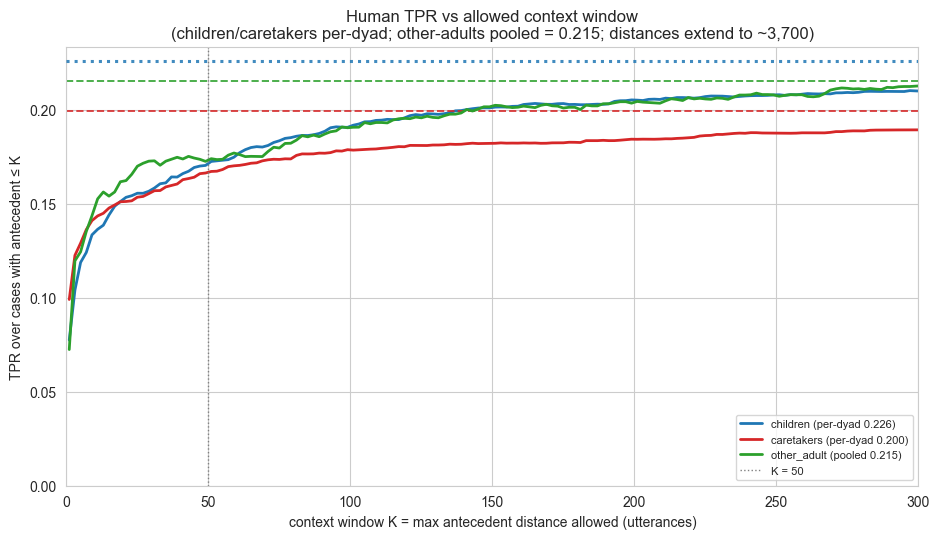

In [20]:
def _agg(grp, k):
    s = human_dist[(human_dist.group==grp) & (human_dist.dist<=k)]
    return s.switch.mean() if grp=="other_adult" else s.groupby("child_name").switch.mean().mean()
XMAX = 300
Ks = np.unique(np.linspace(1, XMAX, 150).astype(int))
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for grp, c in GCOL.items():
    avg = _agg(grp, 10**9); tag = "pooled" if grp=="other_adult" else "per-dyad"
    ax.plot(Ks, [_agg(grp, k) for k in Ks], "-", color=c, lw=2, label=f"{grp} ({tag} {avg:.3f})")
    ax.axhline(avg, color=c, ls=(":" if grp=="children" else "--"), lw=(2.2 if grp=="children" else 1.4),
               alpha=0.85, zorder=(3 if grp=="children" else 2))
ax.axvline(50, color="gray", ls=":", lw=1, label="K = 50")
ax.set_xlim(0, XMAX); ax.set_ylim(0, None)
ax.set_xlabel("context window K = max antecedent distance allowed (utterances)")
ax.set_ylabel("TPR over cases with antecedent ≤ K")
ax.set_title("Human TPR vs allowed context window\n(children/caretakers per-dyad; other-adults pooled = 0.215; distances extend to ~3,700)")
ax.legend(fontsize=8); plt.tight_layout()
plt.savefig("figures/human_tpr_vs_window.png", dpi=130, bbox_inches="tight"); plt.show()

In [21]:
# Per-K table: per-group TPR + n, one-sample (vs pooled other-adult at K), paired children-vs-caretakers
def _pdvals(grp, k):
    return human_dist[(human_dist.group==grp) & (human_dist.dist<=k)].groupby("child_name").switch.mean().dropna()
_rows = []
for k in [1, 3, 5, 10, 20, 50, 100, 10**9]:
    s_oa = human_dist[(human_dist.group=="other_adult") & (human_dist.dist<=k)]
    oa_ref, oa_n = s_oa.switch.mean(), len(s_oa)
    cv, mv = _pdvals("children", k), _pdvals("caretakers", k)
    ct, cp = ttest_1samp(cv, oa_ref); mt, mp = ttest_1samp(mv, oa_ref)
    ix = cv.index.intersection(mv.index); cc_t, cc_p = ttest_rel(cv.loc[ix], mv.loc[ix])
    _rows.append(dict(K=("all" if k>10**8 else str(k)),
        child_TPR=round(cv.mean(),3),     child_n=int(((human_dist.group=="children")&(human_dist.dist<=k)).sum()),
        child_t=round(ct,3),  child_p=round(cp,3),
        caretaker_TPR=round(mv.mean(),3), caretaker_n=int(((human_dist.group=="caretakers")&(human_dist.dist<=k)).sum()),
        caretaker_t=round(mt,3), caretaker_p=round(mp,3), cc_t=round(cc_t,3), cc_p=round(cc_p,3),
        otherAdult_pooledTPR=round(oa_ref,3), otherAdult_n=oa_n))
human_switch_by_window = pd.DataFrame(_rows)
human_switch_by_window.to_csv("results/tpr/human_switch_rate_by_window.csv", index=False)
print(human_switch_by_window.to_string(index=False))

# Window-matched reference table for the LM analysis: pooled other-adult TPR (and children per-dyad) for dist<=K
_wrows = []
for k in list(range(1, 201)) + [10**9]:
    cc = human_dist[(human_dist.group=="children") & (human_dist.dist<=k)].groupby("child_name").switch.mean()
    oa = human_dist[(human_dist.group=="other_adult") & (human_dist.dist<=k)]
    _wrows.append(dict(K=(10**9 if k>10**8 else k), children_perdyad_TPR=cc.mean(),
                       other_adult_pooled_TPR=oa.switch.mean(), other_adult_n=len(oa)))
pd.DataFrame(_wrows).to_csv("results/tpr/human_tpr_by_window.csv", index=False)
print("\nsaved results/tpr/human_tpr_by_window.csv (window-matched references for the LM analysis)")

  K  child_TPR  child_n  child_t  child_p  caretaker_TPR  caretaker_n  caretaker_t  caretaker_p   cc_t  cc_p  otherAdult_pooledTPR  otherAdult_n
  1      0.077     1067    0.453    0.660          0.099         3012        2.301        0.042 -2.762 0.018                 0.072           207
  3      0.104     1900   -1.214    0.250          0.123         4267        0.268        0.794 -2.204 0.050                 0.120           376
  5      0.119     2306   -0.417    0.685          0.129         4611        0.423        0.681 -1.115 0.289                 0.124           466
 10      0.135     2729   -1.304    0.219          0.142         4952       -0.976        0.350 -0.697 0.500                 0.154           559
 20      0.152     3163   -0.671    0.516          0.151         5264       -0.907        0.384  0.075 0.942                 0.162           649
 50      0.172     3731   -0.150    0.884          0.167         5654       -0.552        0.592  0.364 0.722                 0.174


saved results/tpr/human_tpr_by_window.csv (window-matched references for the LM analysis)


### Antecedent-distance distribution and the far tail

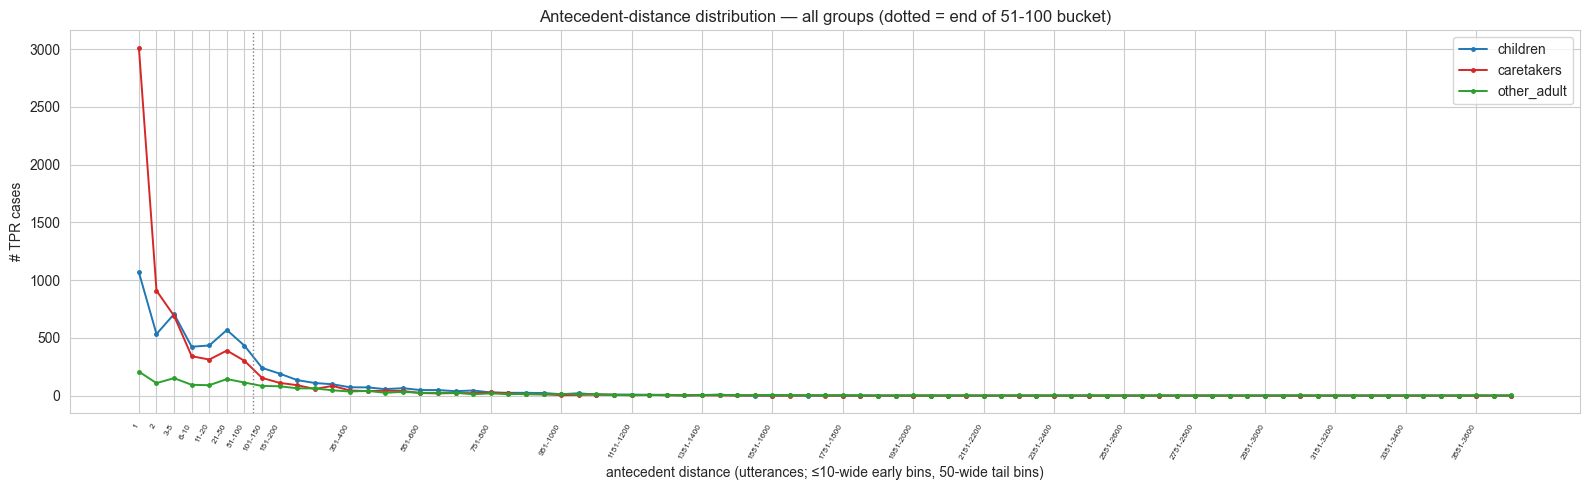

percentiles of antecedent distance:
      children  caretakers  other_adult
p50        11           2           56
p75       101          15          322
p90       397         160          739
p95       641         376         1038
p99      1072         843         1658
max      1716        1667         3687

TPR by near/far antecedent:
       group    n  median_dist  pct_gt50  TPR_all  TPR_le50  TPR_gt50
   children 5562           11        33    0.226     0.172     0.327
 caretakers 6812            2        17    0.200     0.167     0.348
other_adult 1615           56        51    0.231     0.193     0.270


In [22]:
mx = int(human_dist.dist.max())
edges = [0,1,2,5,10,20,50,100] + list(range(150, mx+50, 50))
labels = [(f"{b}" if b-a==1 else f"{a+1}-{b}") for a,b in zip(edges[:-1], edges[1:])]
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(16, 5))
for grp, c in GCOL.items():
    cnt = pd.cut(human_dist[human_dist.group==grp].dist, bins=edges, labels=labels, right=True).value_counts().reindex(labels).fillna(0)
    ax.plot(x, cnt.values, "-", color=c, lw=1.4, marker="o", ms=2.5, label=grp)
ax.axvline(6.5, color="gray", ls=":", lw=1)
tick_i = list(range(8)) + list(range(8, len(labels), 4))
ax.set_xticks(tick_i); ax.set_xticklabels([labels[i] for i in tick_i], rotation=60, ha="right", fontsize=6)
ax.set_xlabel("antecedent distance (utterances; ≤10-wide early bins, 50-wide tail bins)")
ax.set_ylabel("# TPR cases"); ax.set_title("Antecedent-distance distribution — all groups (dotted = end of 51-100 bucket)")
ax.legend(); plt.tight_layout()
plt.savefig("figures/human_antecedent_distance_hist.png", dpi=130, bbox_inches="tight"); plt.show()

# full-range counts + percentiles + far/near TPR breakdown
counts = pd.DataFrame({grp: pd.cut(human_dist[human_dist.group==grp].dist, bins=edges, labels=labels, right=True)
                            .value_counts().reindex(labels) for grp in GCOL})
counts["all"] = counts.sum(axis=1); counts.to_csv("results/tpr/human_antecedent_distance_counts.csv")
pct = pd.DataFrame({grp: np.percentile(human_dist[human_dist.group==grp].dist, [50,75,90,95,99,100]) for grp in GCOL},
                   index=["p50","p75","p90","p95","p99","max"]).astype(int)
print("percentiles of antecedent distance:\n", pct.to_string())
_srows = []
for grp in GCOL:
    s = human_dist[human_dist.group==grp]
    _srows.append(dict(group=grp, n=len(s), median_dist=int(s.dist.median()), pct_gt50=round(100*(s.dist>50).mean()),
        TPR_all=round(_pd_tpr(s),3), TPR_le50=round(_pd_tpr(s[s.dist<=50]),3), TPR_gt50=round(_pd_tpr(s[s.dist>50]),3)))
tpr_by_distance = pd.DataFrame(_srows); tpr_by_distance.to_csv("results/tpr/human_tpr_by_distance_summary.csv", index=False)
print("\nTPR by near/far antecedent:\n", tpr_by_distance.to_string(index=False))

**Why the baseline is what it is.** Switching is rare for recent antecedents (~0.07–0.17 at
≤50 utterances) and roughly doubles for far ones (>50). The other-adult baseline is far-antecedent
dominated (median ~56, ~51% beyond 50), which is what lifts its pooled TPR to **0.215**; children's
and caretakers' antecedents are more recent. So the 0.215 reference reflects a far-antecedent-heavy
corpus — the LM analysis (`lm_tpr_analysis.ipynb`) uses the window-matched references exported here
(`human_tpr_by_window.csv`) to compare context-limited models fairly.

## 7. Exports

Write the human-side artifacts consumed downstream:
- `tpr_human_summary.csv` — per-speaker aggregate TPR + statistical tests (used by `analysis.ipynb`).
- `tpr_human_perdyad_references.csv` — per-dyad unrestricted TPRs for children, caretakers, and
  other-adults; the reference distributions consumed by **`lm_tpr_analysis.ipynb`** to run the
  four per-model TPR tests (Welch vs other-adult dyads, one-sample vs the pooled adult mean,
  paired vs Manchester children, paired vs Manchester caretakers).

In [23]:
# 1-sample tests: Manchester humans vs ADULT_TPR_POPULATION_MEAN
_, p_child_1sample = ttest_1samp(old_child_tprs_unres, unrestricted_global_tpr)
_, p_mother_1sample = ttest_1samp(old_mother_tprs_unres, unrestricted_global_tpr)

# Welch tests: Manchester humans vs other-adult dyads
_, p_child_welch_vs_adults = ttest_ind(old_child_tprs_unres, unrestricted_oa_tprs, equal_var=False)
_, p_mother_welch_vs_adults = ttest_ind(old_mother_tprs_unres, unrestricted_oa_tprs, equal_var=False)

# Paired test: Manchester children vs Manchester caretakers
_, p_child_vs_caretaker = ttest_rel(old_child_tprs_unres, old_mother_tprs_unres)

human_summary = pd.DataFrame([
    {
        "speaker": "child", "corpus": "manchester",
        "n_dyads": int(len(old_child_tprs_unres)),
        "mean_tpr": float(old_child_tprs_unres.mean()),
        "sd_tpr": float(old_child_tprs_unres.std(ddof=1)),
        "p_validation": float(p_val_child_validation),
        "p_1sample": float(p_child_1sample),
        "p_welch_vs_adults": float(p_child_welch_vs_adults),
        "p_child_vs_caretaker": float(p_child_vs_caretaker),
        "adult_tpr_population_mean": float(unrestricted_global_tpr),
    },
    {
        "speaker": "mother", "corpus": "manchester",
        "n_dyads": int(len(old_mother_tprs_unres)),
        "mean_tpr": float(old_mother_tprs_unres.mean()),
        "sd_tpr": float(old_mother_tprs_unres.std(ddof=1)),
        "p_validation": float(p_val_mother_validation),
        "p_1sample": float(p_mother_1sample),
        "p_welch_vs_adults": float(p_mother_welch_vs_adults),
        "p_child_vs_caretaker": float(p_child_vs_caretaker),
        "adult_tpr_population_mean": float(unrestricted_global_tpr),
    },
    {
        "speaker": "other_adult", "corpus": "tpr_data",
        "n_dyads": int(len(unrestricted_oa_tprs)),
        "mean_tpr": float(unrestricted_oa_tprs.mean()),
        "sd_tpr": float(unrestricted_oa_tprs.std(ddof=1)),
        "p_validation": np.nan,
        "p_1sample": np.nan,
        "p_welch_vs_adults": np.nan,
        "p_child_vs_caretaker": np.nan,
        "adult_tpr_population_mean": float(unrestricted_global_tpr),
    },
])

out_path = "./results/tpr/tpr_human_summary.csv"
os.makedirs(os.path.dirname(out_path), exist_ok=True)
human_summary.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(human_summary.round(4).to_string(index=False))


Saved: ./results/tpr/tpr_human_summary.csv
    speaker     corpus  n_dyads  mean_tpr  sd_tpr  p_validation  p_1sample  p_welch_vs_adults  p_child_vs_caretaker  adult_tpr_population_mean
      child manchester       12    0.2259  0.0497        0.5549     0.4842             0.8101                0.0637                     0.2155
     mother manchester       12    0.1996  0.0459        0.7829     0.2560             0.1200                0.0637                     0.2155
other_adult   tpr_data       17    0.2308  0.0584           NaN        NaN                NaN                   NaN                     0.2155


In [24]:
# Per-dyad unrestricted reference TPRs consumed by lm_tpr_analysis.ipynb for the model TPR tests.
# Long format: one row per (speaker, dyad). children/caretakers are the Manchester per-dyad
# aggregates; other_adult are the 17 tpr-data dyads. These exactly reconstruct old_child_ref,
# old_mother_ref and the other-adult Welch sample used previously in-notebook.
_ref_rows = []
for _spk, _src, _col in [
    ("child",        old_unrestricted_agg,  "old_tpr_unrestricted"),
    ("mother",       old_unrestricted_agg,  "old_tpr_unrestricted"),
    ("other_adult",  unrestricted_new_agg,  "new_tpr_unrestricted"),
]:
    _s = _src[_src["speaker"] == _spk].dropna(subset=[_col])
    for _, _r in _s.iterrows():
        _ref_rows.append({"speaker": _spk, "child_name_norm": _r["child_name_norm"],
                          "tpr_unrestricted": float(_r[_col])})
human_perdyad_refs = pd.DataFrame(_ref_rows)
_ref_path = "./results/tpr/tpr_human_perdyad_references.csv"
human_perdyad_refs.to_csv(_ref_path, index=False)
print(f"Saved: {_ref_path}  ({dict(human_perdyad_refs.speaker.value_counts())})")

Saved: ./results/tpr/tpr_human_perdyad_references.csv  ({'other_adult': np.int64(17), 'child': np.int64(12), 'mother': np.int64(12)})
